In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
url = "https://raw.githubusercontent.com/nkmwicz/data-for-students/refs/heads/main/soccer-players.csv"
df = pd.read_csv(url)
df.head()

,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,foot,height_in_cm,contract_expiration_date,agent_name,image_url,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
0,10,Miroslav,Klose,Miroslav Klose,2015,398,miroslav-klose,Poland,Opole,Germany,...,right,184.0,NaN,ASBW Sport Marketing,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/miroslav-klose...,IT1,Società Sportiva Lazio S.p.A.,1000000.0,30000000.0
1,26,Roman,Weidenfeller,Roman Weidenfeller,2017,16,roman-weidenfeller,Germany,Diez,Germany,...,left,190.0,NaN,Neubauer 13 GmbH,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/roman-weidenfe...,L1,Borussia Dortmund,750000.0,8000000.0
2,65,Dimitar,Berbatov,Dimitar Berbatov,2015,1091,dimitar-berbatov,Bulgaria,Blagoevgrad,Bulgaria,...,NaN,NaN,NaN,CSKA-AS-23 Ltd.,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/dimitar-berbat...,GR1,Panthessalonikios Athlitikos Omilos Konstantin...,1000000.0,34500000.0
3,77,NaN,Lúcio,Lúcio,2012,506,lucio,Brazil,Brasília,Brazil,...,NaN,NaN,NaN,NaN,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/lucio/profil/s...,IT1,Juventus Football Club,200000.0,24500000.0
4,80,Tom,Starke,Tom Starke,2017,27,tom-starke,East Germany (GDR),Freital,Germany,...,right,194.0,NaN,IFM,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/tom-starke/pro...,L1,FC Bayern München,100000.0,3000000.0


In [6]:
df["bmonth"] = pd.to_datetime(df["date_of_birth"])

In [9]:
df["bmonth"] = df["bmonth"].dt.month

In [10]:
positions = df["position"].unique()
bmonths = df["bmonth"].unique()
positions

array(['Attack', 'Goalkeeper', 'Defender', 'Midfield', 'Missing'],
      dtype=object)

In [12]:
df["bmonth"].isna().sum()

np.int64(47)

In [13]:
df = df.dropna(subset=["position", "bmonth"])

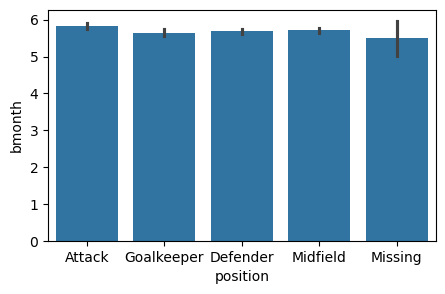

In [14]:
plt.figure(figsize=(5,3))
bar = sns.barplot(data=df, x= "position", y= "bmonth")

<BarContainer object of 12 artists>

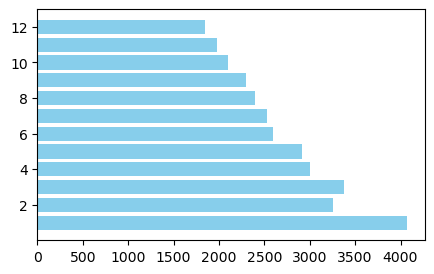

In [15]:
plt.figure(figsize=(5,3))
months = df["bmonth"].unique()
months = sorted(list(months))

bmonth_nums = [df.loc[df["bmonth"] == m, "bmonth"].count() for m in months]

plt.barh(y = months, width = bmonth_nums, color = "skyblue")

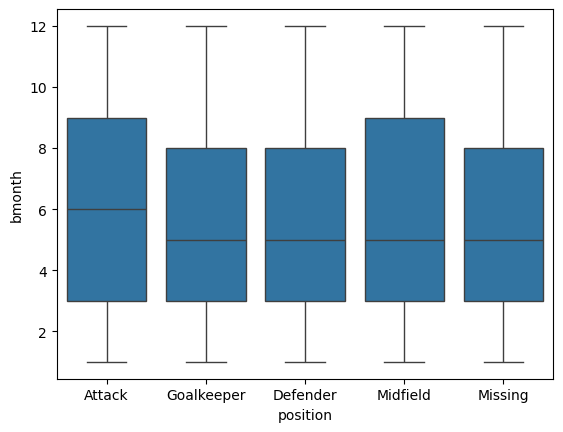

In [16]:
box = sns.boxplot(data=df, x = "position", y = "bmonth")

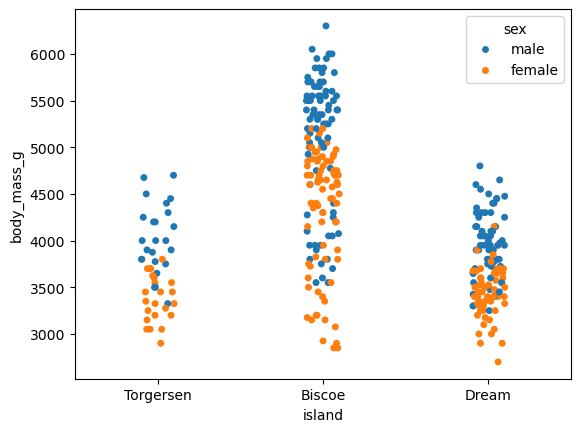

In [18]:
penguins = pd.read_csv("https://raw.githubusercontent.com/dataprofessor/data/refs/heads/master/penguins_cleaned.csv")

strip = sns.stripplot(data=penguins, x = "island", y = "body_mass_g", hue = "sex")

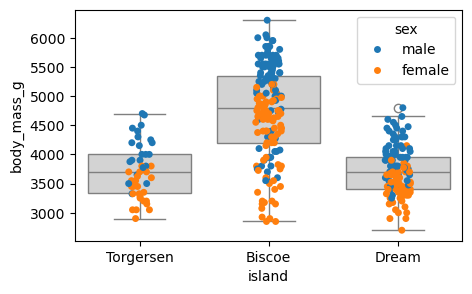

In [19]:
plt.figure(figsize=(5,3))
box = sns.boxplot(data=penguins, x = "island", y = "body_mass_g", color = "lightgrey")
strip = sns.stripplot(data=penguins, x = "island", y = "body_mass_g", hue = "sex")

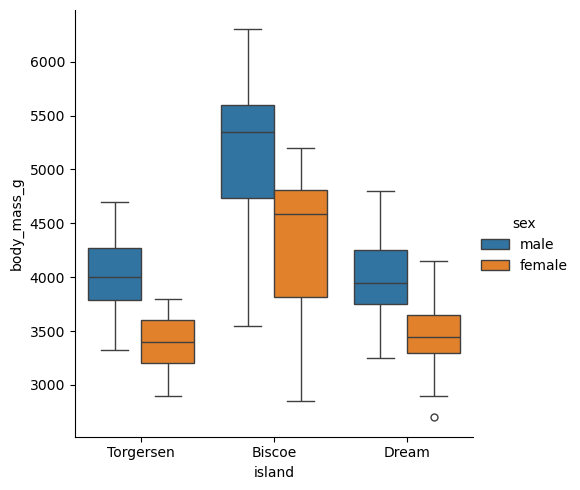

In [20]:
sns.catplot(data=penguins, x = "island", y = "body_mass_g", hue = "sex", kind = "box")

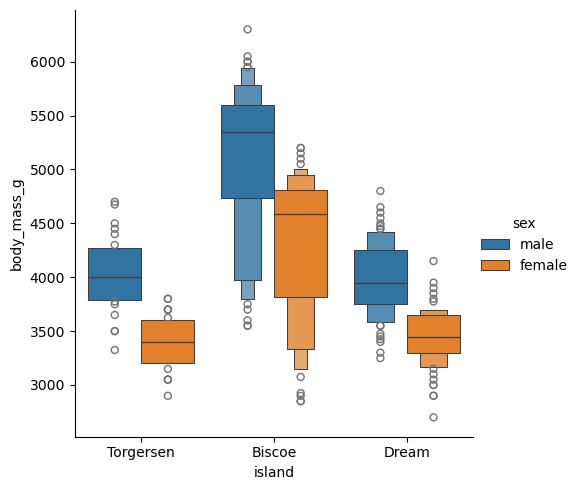

In [21]:
sns.catplot(data=penguins, x = "island", y = "body_mass_g", hue = "sex", kind = "boxen")

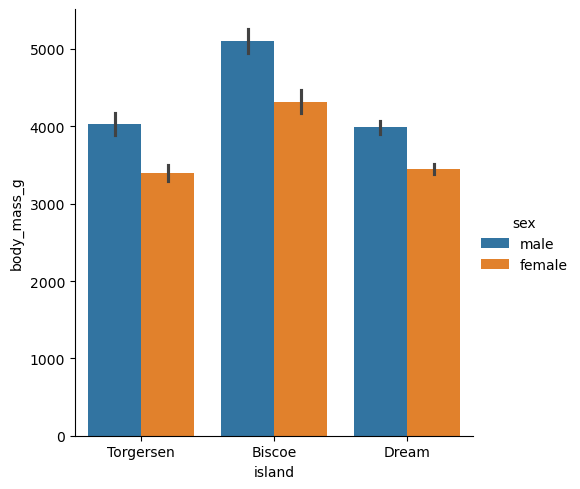

In [22]:
sns.catplot(data=penguins, x = "island", y = "body_mass_g", hue = "sex", kind = "bar")

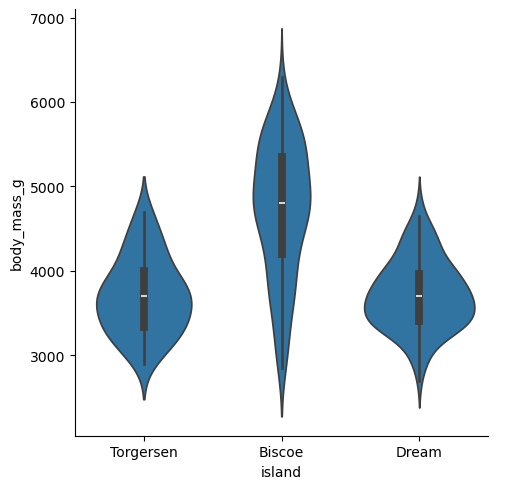

In [23]:
sns.catplot(data=penguins, x = "island", y = "body_mass_g", kind = "violin")

<Axes: xlabel='position', ylabel='bmonth'>

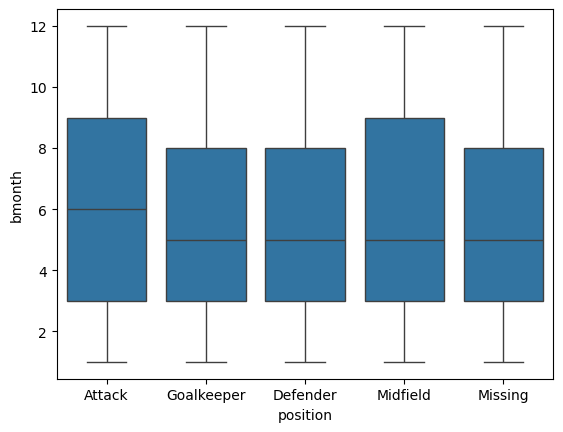

In [24]:
sns.boxplot(data=df, x = "position", y = "bmonth")

In [25]:
bmonths = [df.loc[df['position'] == pos, 'bmonth'] for pos in positions]
f, p = stats.f_oneway(*bmonths)
dfb = len(positions) - 1
dfw = len(df) - len(positions)
alpha = 0.05
critical = stats.f.ppf(1- alpha, dfb, dfw)
print(f"f={f:.4f}, p={p:.4f}, critical={critical:.4f}")

f=3.2134, p=0.0120, critical=2.3722


In [26]:
tukey = stats.tukey_hsd(*bmonths)
print(tukey)
print(positions)

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)      0.183     0.049     0.001     0.366
 (0 - 2)      0.146     0.027     0.011     0.281
 (0 - 3)      0.124     0.103    -0.014     0.263
 (0 - 4)      0.337     0.686    -0.365     1.040
 (1 - 0)     -0.183     0.049    -0.366    -0.001
 (1 - 2)     -0.037     0.979    -0.216     0.141
 (1 - 3)     -0.059     0.902    -0.240     0.122
 (1 - 4)      0.154     0.977    -0.558     0.866
 (2 - 0)     -0.146     0.027    -0.281    -0.011
 (2 - 1)      0.037     0.979    -0.141     0.216
 (2 - 3)     -0.022     0.992    -0.155     0.112
 (2 - 4)      0.191     0.946    -0.510     0.893
 (3 - 0)     -0.124     0.103    -0.263     0.014
 (3 - 1)      0.059     0.902    -0.122     0.240
 (3 - 2)      0.022     0.992    -0.112     0.155
 (3 - 4)      0.213     0.922    -0.489     0.915
 (4 - 0)     -0.337     0.686    -1.040     0.365
 (4 - 1)     -0.154     0.977    -0.866     

from this we see that attackers have a higher birth month than goalkeepers (which means that they are born later in the year so they are younger than their peers)

reject null bc attackers have a statistically meaningful difference between birth months in comparison to goalkeepers 

attackers also have later birth months than defenders 

reject null there is a statistically meaningful difference between attackers and defenders 


attackers are born later in the year but only in comparison to goalkeepers and defenders 

In [30]:
diff =bmonths[0].mean() - bmonths[1].mean()
diff * 30 #days

np.float64(5.493614679340908)

In [31]:
diff =bmonths[0].mean() - bmonths[2].mean()
diff * 30 #days

np.float64(4.372208902480033)